In [1]:
# Import essential libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/machine_failure_prediction_dataset.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

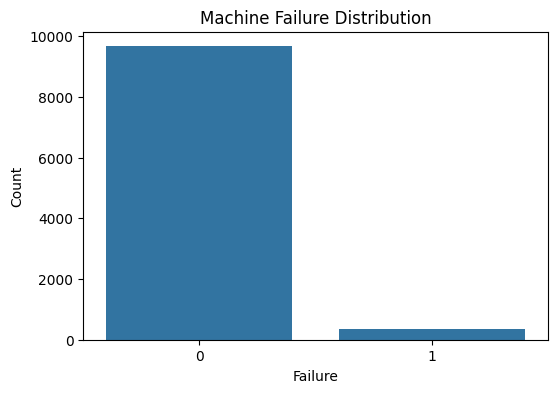

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Machine failure', data=df)
plt.title("Machine Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")
plt.show()

In [11]:
corr = df.corr(numeric_only=True)
corr

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


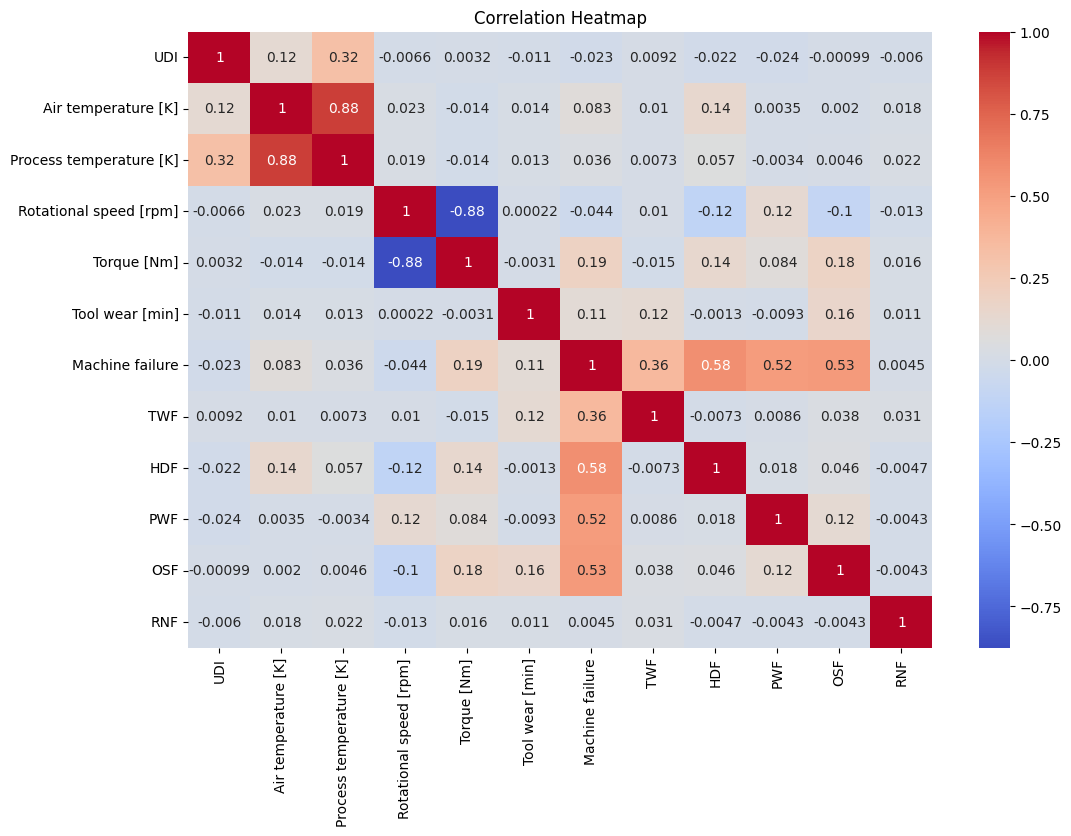

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

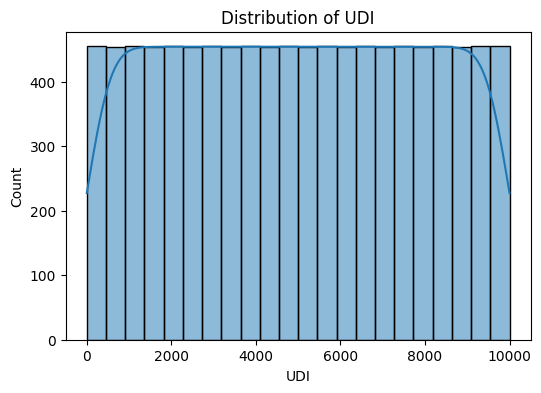

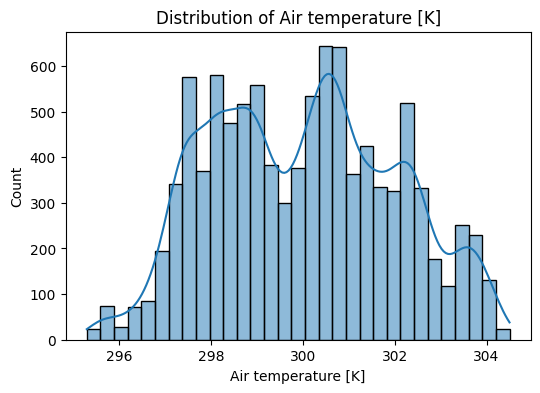

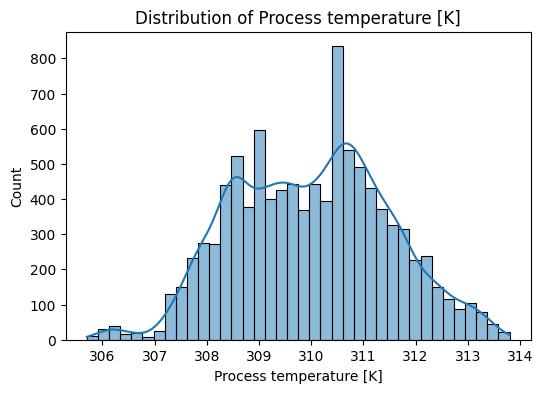

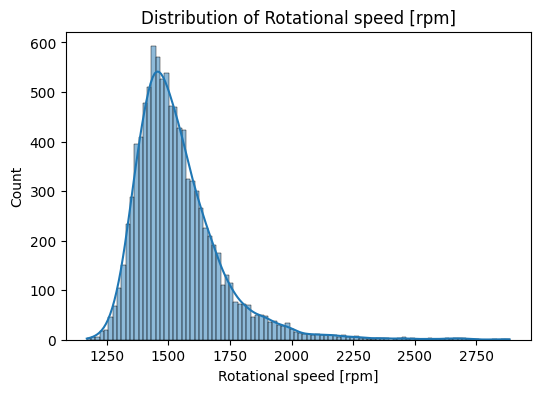

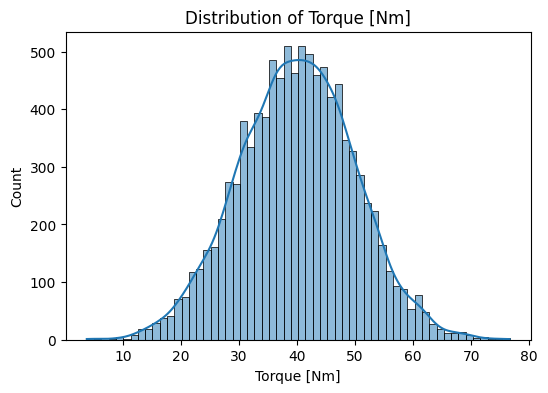

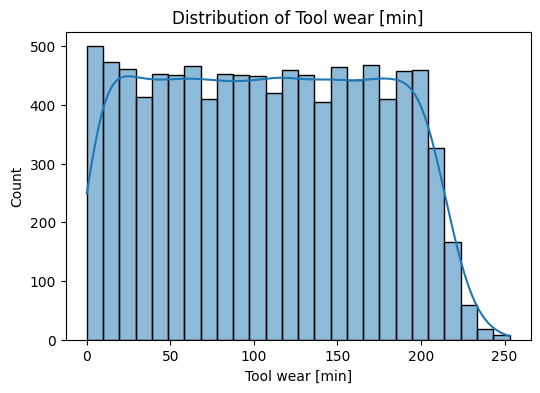

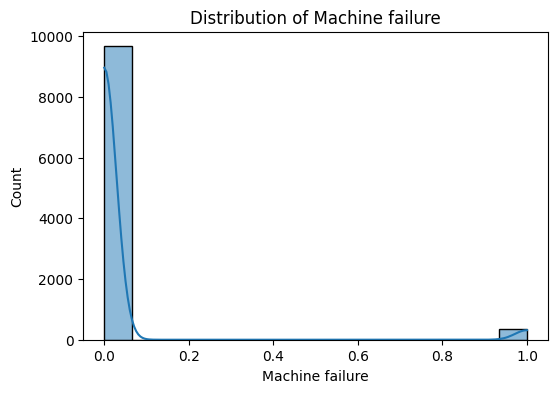

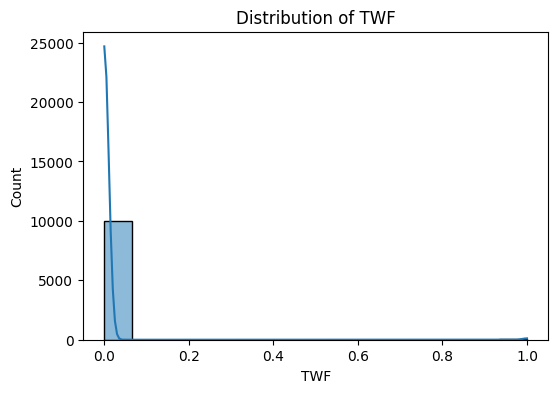

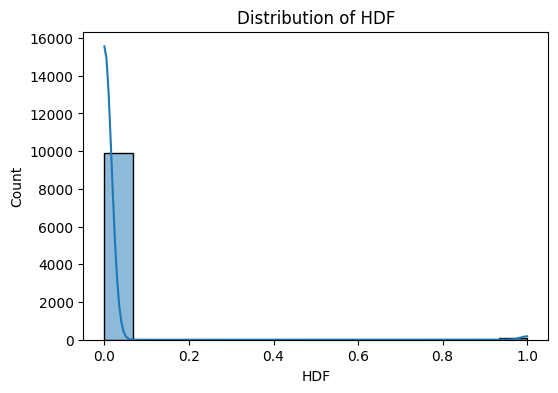

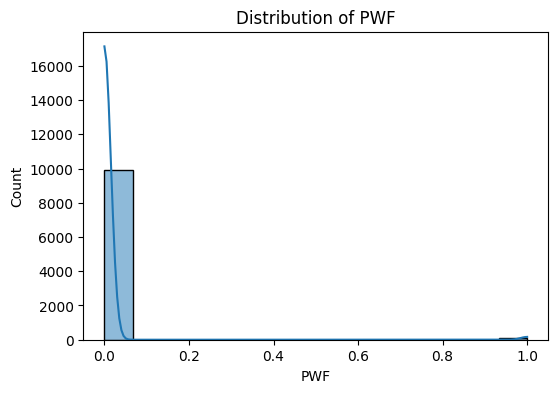

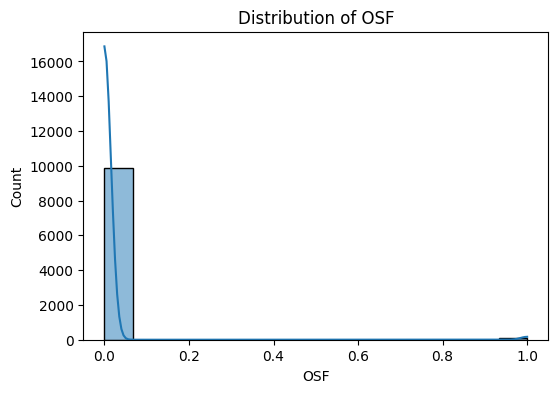

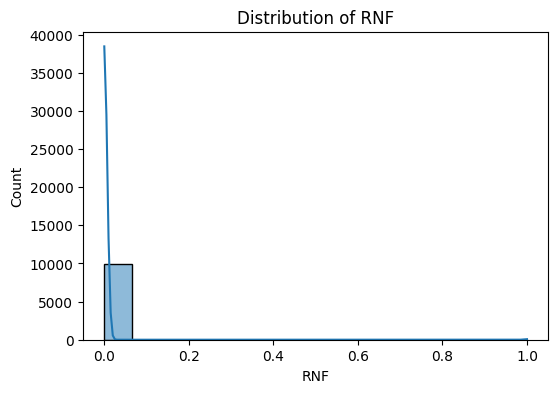

In [13]:
# Visualize distribution of all numerical features using histograms with KDE curves to identify skewness and outliers
numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

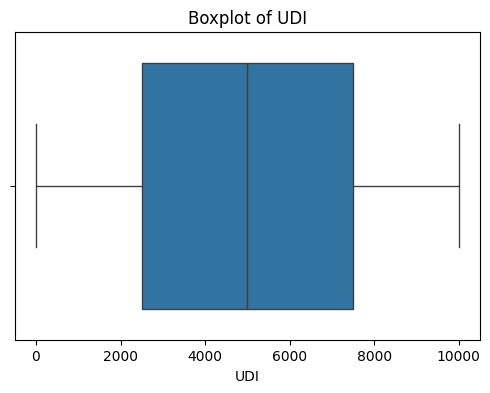

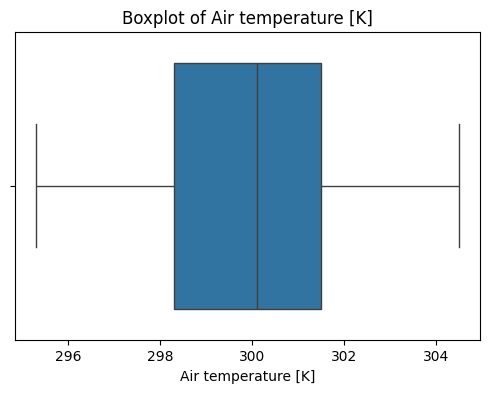

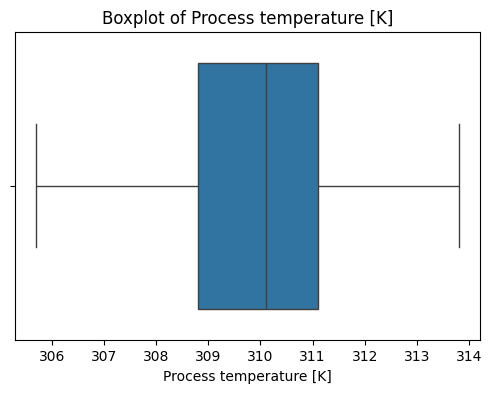

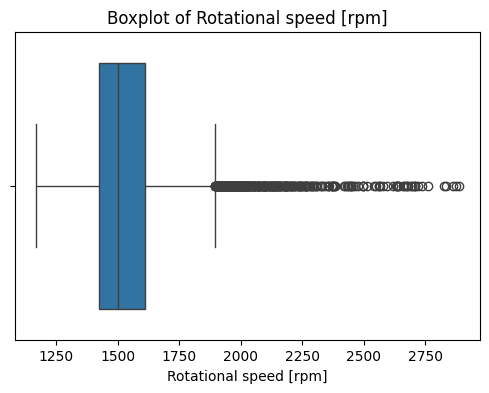

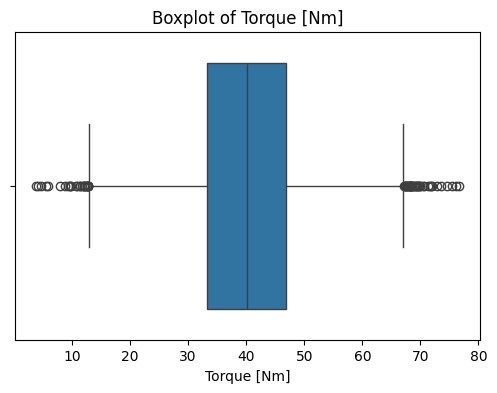

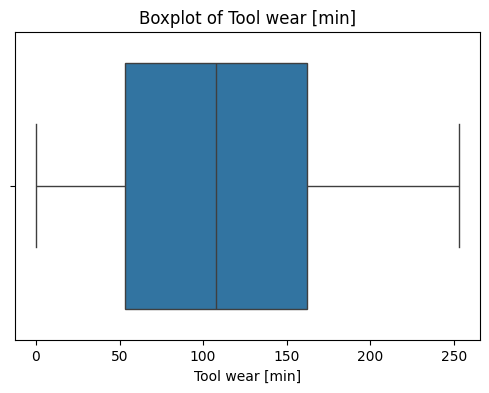

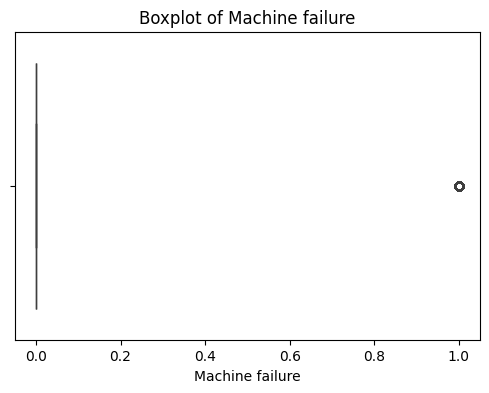

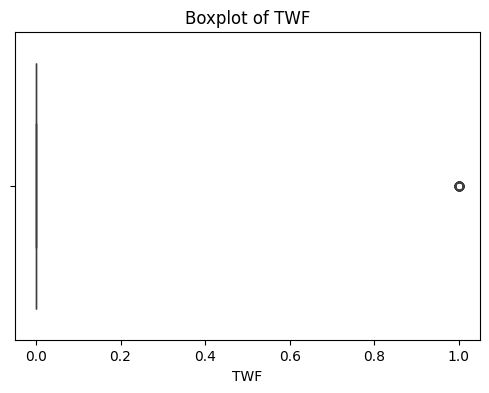

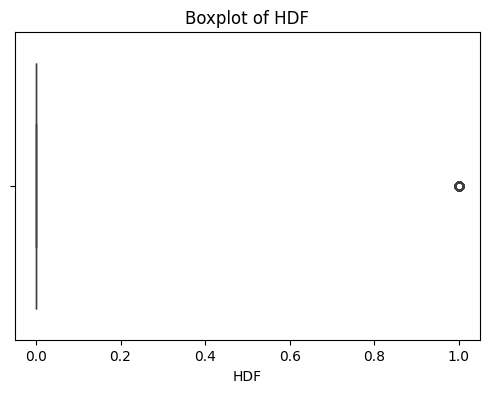

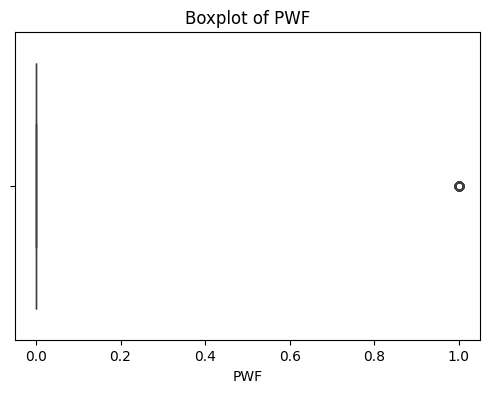

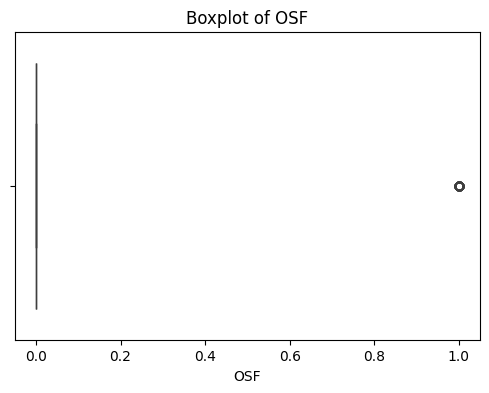

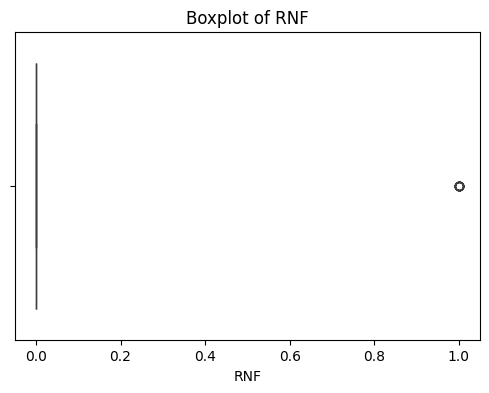

In [14]:
# Detect outliers and analyze spread of numerical features using boxplots for each column
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

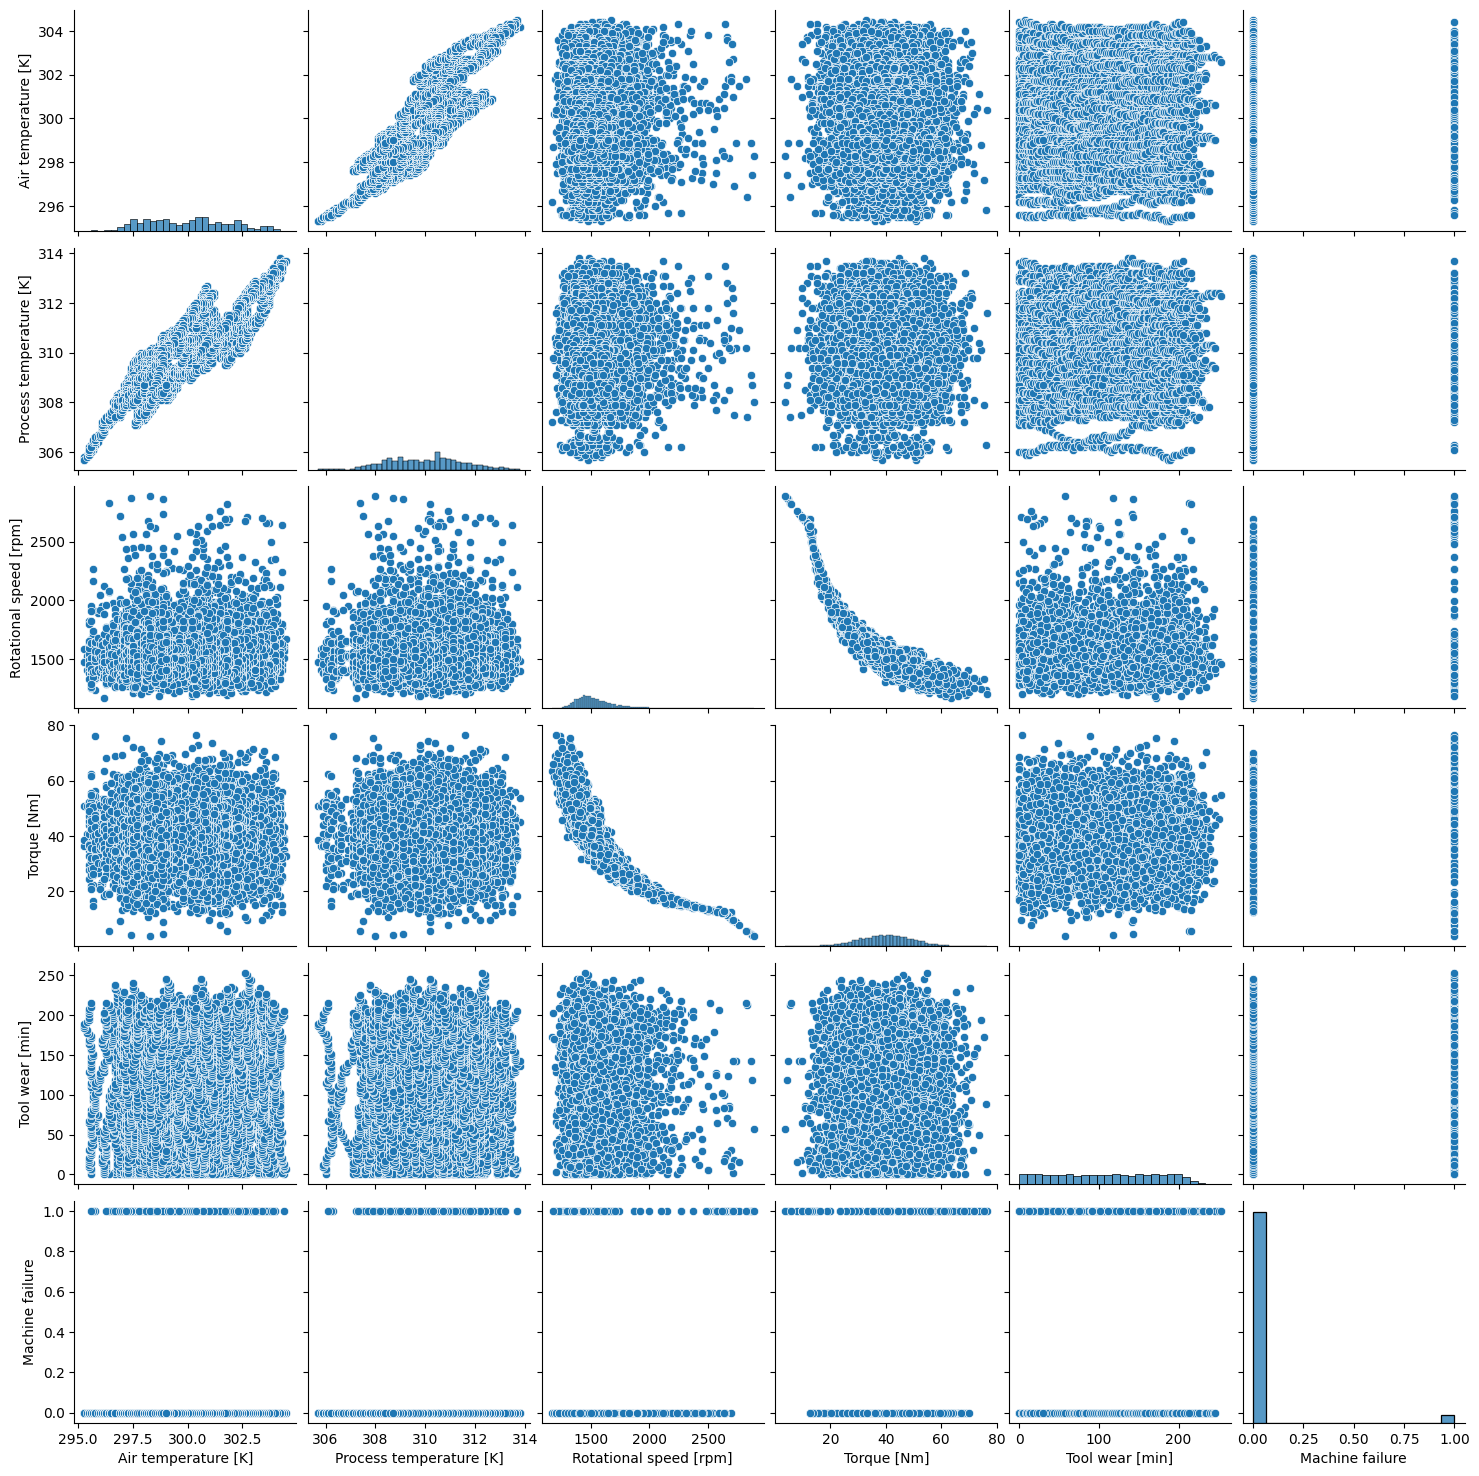

In [15]:
# Analyze pairwise relationships between key numerical features and the target variable to identify patterns
sns.pairplot(df[['Air temperature [K]',
                 'Process temperature [K]',
                 'Rotational speed [rpm]',
                 'Torque [Nm]',
                 'Tool wear [min]',
                 'Machine failure']])
plt.show()

In [16]:
df.select_dtypes(include='object').columns

Index(['Product ID', 'Type'], dtype='object')

In [17]:
# Convert categorical 'Type' column to numeric labels (0, 1, 2...) for machine learning model compatibility
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

In [18]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
machine_ids = df[['UDI', 'Product ID']]
machine_ids

,UDI,Product ID
0,1,M14860
1,2,L47181
2,3,L47182
3,4,L47183
4,5,L47184
...,...,...
9995,9996,M24855
9996,9997,H39410
9997,9998,M24857
9998,9999,H39412


In [20]:
ml_df = df.drop(['UDI', 'Product ID'], axis=1)
ml_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [21]:
# Separate features (X) and target variable (Y) for model training - Y contains machine failure labels (0/1)
X = ml_df.drop('Machine failure', axis=1)
Y = ml_df['Machine failure']

In [22]:
X.shape

(10000, 11)

In [23]:
Y.shape

(10000,)

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
# Split data into training (80%) and testing (20%) sets with fixed random seed for reproducibility
x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [26]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [27]:

from xgboost import XGBClassifier

In [28]:
X.columns = X.columns.str.replace(r'[\[\]<>]', '', regex=True)
x_train.columns = x_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
x_test.columns = x_test.columns.str.replace(r'[\[\]<>]', '', regex=True)

In [29]:
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

In [32]:
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.999
Precision: 1.0
Recall   : 0.9672131147540983
F1 Score : 0.9833333333333333

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



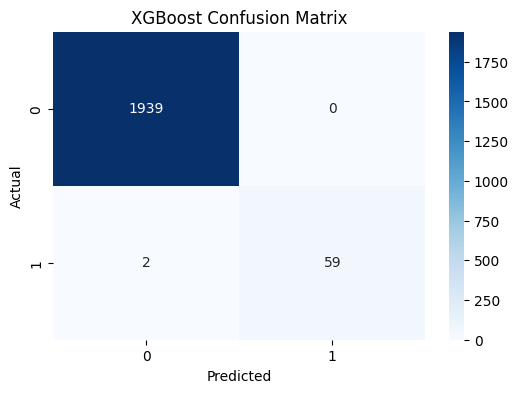

In [34]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [35]:
# Feature Importance

importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

                  Feature  Importance
7                     HDF    0.416282
9                     OSF    0.311773
8                     PWF    0.188093
6                     TWF    0.081241
3    Rotational speed rpm    0.000497
4               Torque Nm    0.000446
2   Process temperature K    0.000431
5           Tool wear min    0.000430
1       Air temperature K    0.000414
0                    Type    0.000392
10                    RNF    0.000000


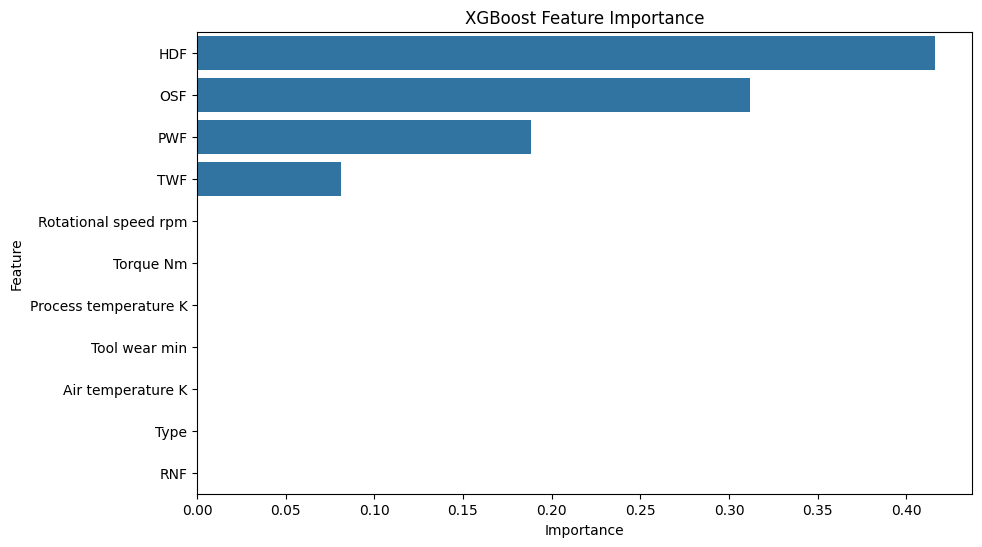

In [36]:
# Visualize Feature Importance

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)
plt.title("XGBoost Feature Importance")
plt.show()

In [37]:
# Save Trained XGBoost Model
import joblib
joblib.dump(
    xgb_model,
    "../models/xgboost_machine_failure_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [38]:
# Load Saved Model

loaded_model = joblib.load(
    "../models/xgboost_machine_failure_model.pkl"
)
print("Model loaded successfully")

Model loaded successfully


In [49]:
sample_data = pd.DataFrame({
    'Type': [1],
    'Air temperature K': [330],
    'Process temperature K': [360],
    'Rotational speed rpm': [2500],
    'Torque Nm': [85],
    'Tool wear min': [250],
    'TWF': [0],
    'HDF': [0],
    'PWF': [0],
    'OSF': [0],
    'RNF': [0]
})

prediction = xgb_model.predict(sample_data)
failure_prob = xgb_model.predict_proba(sample_data)

if prediction[0] == 1:
    print("Machine Failure Predicted")
else:
    print("Machine is Healthy")

print("Healthy Probability :", failure_prob[0][0])
print("Failure Probability :", failure_prob[0][1])

Machine is Healthy
Healthy Probability : 0.9617045
Failure Probability : 0.03829548


In [50]:
prediction = xgb_model.predict(sample_data)
failure_prob = xgb_model.predict_proba(sample_data)

In [51]:
health_score = (1 - failure_prob[0][1]) * 100
if health_score > 80:
    risk = "Low Risk"
elif health_score > 50:
    risk = "Medium Risk"
else:
    risk = "High Risk"

In [52]:
# Extract values from sample data
tool_wear = sample_data['Tool wear min'].values[0]
torque = sample_data['Torque Nm'].values[0]
process_temp = sample_data['Process temperature K'].values[0]

recommendation = []

if tool_wear > 200:
    recommendation.append("Replace tool within 2 days")

if torque > 80:
    recommendation.append("Inspect mechanical components")

if process_temp > 350:
    recommendation.append("Check cooling system")

if not recommendation:
    recommendation.append("No immediate maintenance required")

print(f"Health Score: {health_score:.2f}%")
print(f"Risk Level: {risk}")
print("Recommendations:")
for rec in recommendation:
    print(f"  - {rec}")

Health Score: 96.17%
Risk Level: Low Risk
Recommendations:
  - Replace tool within 2 days
  - Inspect mechanical components
  - Check cooling system
